# RAG Testing & Drift Detection: A Complete Walkthrough

This notebook demonstrates how to **test a RAG pipeline**, **detect when it degrades**, and **simulate failures** to validate your monitoring works.

## What You'll See

| Phase | What Happens | Expected Outcome |
|-------|-------------|-----------------|
| **Phase 1: Baseline** | 50 good queries establish "normal" | Metrics: precision ~0.9, faithfulness ~0.7 |
| **Phase 2: Normal traffic** | 20 queries, no failures | No alerts, metrics stay in baseline band |
| **Phase 3: Retrieval noise** | Irrelevant chunks injected | Precision drops, drift alert fires |
| **Phase 4: Model degradation** | LLM ignores context | Faithfulness drops, drift alert fires |
| **Phase 5: Live RAG** | Real queries to local Qwen LLM | See real RAG quality with Phoenix tracing |
| **Phase 6: Dashboard** | Compare all phases | Visual proof of what "healthy" vs "broken" looks like |

## The Testing Checklist

| Category | What to Test | Why It Matters |
|----------|-------------|---------------|
| Retrieval Quality | Precision@K, NDCG, MRR | Is your vector DB finding the right chunks? |
| Generation Quality | Faithfulness, relevance, hallucination rate | Is your LLM using the retrieved content properly? |
| End-to-End Accuracy | Answer correctness vs. ground truth | Does the full pipeline produce right answers? |
| Performance/Latency | P50/P95/P99 latency, throughput | Will it scale? Will users wait? |
| Data Freshness | Dynamic updates, stale content detection | Does it handle changing facts? |
| Security/Safety | Prompt injection, data poisoning, PII leakage | Can attackers exploit your RAG? |
| Robustness | Noise handling, missing context, ambiguous queries | Does it degrade gracefully? |
| Cost Efficiency | Token usage, embedding costs, cache hit rates | Are you burning money unnecessarily? |
| User Experience | Answer completeness, tone, citation quality | Will users actually trust and use it? |

In [1]:
import sys, os, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

# Import our testing system
from rag_testing_system import (
    RAGTestingSystem, SyntheticRAGData, MetricsCalculator,
    RetrievedChunk, RAGResult, DriftAlert
)

print("Imports OK")

# Check LLM availability for Phase 5
from openai import OpenAI
LLM_BASE = "http://127.0.0.1:8001/v1"
try:
    _client = OpenAI(base_url=LLM_BASE, api_key="not-needed")
    _models = _client.models.list()
    MODEL = _models.data[0].id
    print(f"LLM available: {MODEL}")
except:
    MODEL = None
    print("LLM not available (Phase 5 will use synthetic data)")

# Check Phoenix
try:
    import urllib.request
    urllib.request.urlopen("http://localhost:6006", timeout=2)
    print("Phoenix UI: http://localhost:6006")
    PHOENIX_AVAILABLE = True
except:
    PHOENIX_AVAILABLE = False
    print("Phoenix not running (tracing disabled)")

Imports OK


LLM available: unsloth/Qwen3.5-35B-A3B
Phoenix UI: http://localhost:6006


---
## How the Testing System Works

```
                    RAGTestingSystem
                    ┌─────────────────────────────┐
 query + chunks     │                             │
 + answer      ──→  │  1. FailureSimulator        │ ← inject failures (testing only)
                    │     (optional)               │
                    │                             │
                    │  2. MetricsCalculator        │ ← score: precision, recall,
                    │     5 metrics per query      │   faithfulness, relevance, correctness
                    │                             │
                    │  3. DriftDetector            │ ← compare vs baseline
                    │     t-test + Cohen's d       │   alert if degraded
                    │                             │
                    └──────────┬──────────────────┘
                               │
                    ┌──────────▼──────────────────┐
                    │  RAGResult + DriftAlerts     │
                    └─────────────────────────────┘
```

**Key metrics explained:**
- **Contextual Precision**: Are the retrieved chunks actually relevant? Junk chunks confuse the LLM.
- **Contextual Recall**: Did we retrieve ALL the relevant information? Missing context = hallucination risk.
- **Faithfulness**: Does the answer only contain claims supported by the context? LOW = hallucination.
- **Answer Relevance**: Does the answer address the actual question asked?
- **Answer Correctness**: Does the answer match the ground truth? (Only available with test datasets.)

---
## Phase 1: Establish Baseline (50 good queries)

First, we need to know what "healthy" looks like. We generate 50 synthetic queries with correct retrieval and answers, calculate metrics, then set this as our statistical baseline.

**Why 50?** The Central Limit Theorem needs ~30 samples for stable mean/std estimates. 50 gives us a safety margin.

In [2]:
# Generate 50 good-quality results
random.seed(42)  # reproducible
baseline_results = SyntheticRAGData.generate_baseline(n=50)

# Show what a good result looks like
example = baseline_results[0]
print(f"Example query:  {example.query}")
print(f"Answer:         {example.generated_answer}")
print(f"Chunks ({len(example.retrieved_chunks)}):")
for c in example.retrieved_chunks:
    print(f"  [{c.score:.2f}] {c.text[:70]}...")
print(f"\nMetrics:")
print(f"  contextual_precision: {example.contextual_precision:.3f}")
print(f"  contextual_recall:    {example.contextual_recall:.3f}")
print(f"  faithfulness:         {example.faithfulness:.3f}")
print(f"  answer_relevance:     {example.answer_relevance:.3f}")
print(f"  answer_correctness:   {example.answer_correctness:.3f}")

Example query:  Who wrote Romeo and Juliet?
Answer:         William Shakespeare wrote Romeo and Juliet.
Chunks (3):
  [0.80] Romeo and Juliet is a tragedy written by William Shakespeare early in ...
  [0.85] Shakespeare was an English playwright born in 1564....
  [0.84] The play was first published in 1597....

Metrics:
  contextual_precision: 0.667
  contextual_recall:    0.833
  faithfulness:         0.833
  answer_relevance:     0.571
  answer_correctness:   1.000


In [3]:
# Initialize the testing system and set baseline
system = RAGTestingSystem(window_size=100)
baseline_stats = system.establish_baseline(baseline_results)

print("Baseline statistics:")
print(baseline_stats.to_string())
print("\nThese are the numbers we compare against. Any metric dropping")
print("below mean - 2*std triggers a warning; below 3*std triggers critical.")

Baseline statistics:
                          mean       std       p25       p50       p75     n
metric                                                                      
contextual_precision  0.893333  0.157071  0.666667  1.000000  1.000000  50.0
contextual_recall     0.721655  0.207071  0.604167  0.757143  0.833333  50.0
faithfulness          0.714121  0.208226  0.583333  0.714286  0.833333  50.0
answer_relevance      0.318969  0.231615  0.125000  0.333333  0.400000  50.0
answer_correctness    0.984786  0.081785  1.000000  1.000000  1.000000  50.0

These are the numbers we compare against. Any metric dropping
below mean - 2*std triggers a warning; below 3*std triggers critical.


---
## Phase 2: Normal Traffic (20 queries, no failures)

Now we run 20 normal queries. The drift detector should stay quiet.

**What to look for:** All metrics stay within the baseline band (dashed line +/- shaded area in the plots). Zero alerts.

In [4]:
# Run 20 normal queries
print("Phase 2: Normal traffic (expecting NO alerts)\n")
normal_alerts = []

for i in range(20):
    tq = SyntheticRAGData.get_test_query()
    result, alerts = system.test_query(
        query=tq["query"],
        retrieved_chunks=tq["chunks"],
        generated_answer=tq["answer"],
        ground_truth=tq["ground_truth"],
        latency_ms=random.uniform(50, 200),
    )
    if alerts:
        normal_alerts.extend(alerts)
        for a in alerts:
            print(f"  Query {i}: ALERT {a.severity} on {a.metric_name}")

if not normal_alerts:
    print("No alerts (as expected). System is healthy.")
else:
    print(f"\n{len(normal_alerts)} alerts fired (unexpected)")

print(f"\nDashboard after normal traffic:")
print(system.get_dashboard().to_string(index=False))

Phase 2: Normal traffic (expecting NO alerts)

No alerts (as expected). System is healthy.

Dashboard after normal traffic:
              metric  baseline_mean  baseline_std  current_mean  current_n    delta status
contextual_precision       0.893333      0.157071      0.916667         20 0.023333     OK
   contextual_recall       0.721655      0.207071      0.744802         20 0.023147     OK
        faithfulness       0.714121      0.208226      0.744802         20 0.030680     OK
    answer_relevance       0.318969      0.231615      0.367672         20 0.048704     OK
  answer_correctness       0.984786      0.081785      1.000000         20 0.015214     OK


/Users/alexchilton/PycharmProjects/evaluations/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


---
## Phase 3: Retrieval Noise Attack (intensity=0.7)

Now we inject **irrelevant chunks with high similarity scores** into the retrieval results. This simulates what happens when:
- Your embedding model drifts after retraining
- Someone poisons your vector index
- A new document type confuses the retriever

**What to look for:**
- `contextual_precision` drops sharply (junk chunks ranked highly)
- `faithfulness` may drop (LLM gets confused by irrelevant context)
- Drift alert should fire within 5-10 queries

In [5]:
# Enable retrieval noise at 70% intensity
system.enable_simulation("retrieval_noise", intensity=0.7)
print("Phase 3: Retrieval noise ENABLED (intensity=0.7)\n")

noise_alerts = []
for i in range(15):
    tq = SyntheticRAGData.get_test_query()
    result, alerts = system.test_query(
        query=tq["query"],
        retrieved_chunks=tq["chunks"],
        generated_answer=tq["answer"],
        ground_truth=tq["ground_truth"],
        latency_ms=random.uniform(50, 200),
    )
    
    status = ""
    if alerts:
        noise_alerts.extend(alerts)
        for a in alerts:
            status = f"  ALERT [{a.severity.upper()}] {a.metric_name}: baseline={a.baseline_mean:.3f} current={a.current_mean:.3f} Cohen's d={a.drift_score:.2f}"
    
    print(f"  Query {i:2d}: precision={result.contextual_precision:.2f}  "
          f"faithfulness={result.faithfulness:.2f}  relevance={result.answer_relevance:.2f}"
          f"{status}")

system.disable_simulation()
print(f"\nTotal alerts during noise phase: {len(noise_alerts)}")
if noise_alerts:
    print("\nDrift detected! Here are the alerts:")
    for a in noise_alerts:
        print(f"  [{a.severity.upper()}] {a.details}")

Phase 3: Retrieval noise ENABLED (intensity=0.7)

  Query  0: precision=1.00  faithfulness=0.18  relevance=0.05
  Query  1: precision=1.00  faithfulness=0.33  relevance=0.80
  Query  2: precision=0.33  faithfulness=0.20  relevance=0.12
  Query  3: precision=0.00  faithfulness=0.00  relevance=0.57
  Query  4: precision=1.00  faithfulness=0.44  relevance=0.80
  Query  5: precision=0.33  faithfulness=0.00  relevance=0.00
  Query  6: precision=0.00  faithfulness=0.11  relevance=0.00
  Query  7: precision=0.67  faithfulness=0.33  relevance=0.05
  Query  8: precision=0.67  faithfulness=0.58  relevance=0.15
  Query  9: precision=1.00  faithfulness=0.36  relevance=0.33
  Query 10: precision=1.00  faithfulness=1.00  relevance=0.80
  Query 11: precision=0.33  faithfulness=0.19  relevance=0.18
  Query 12: precision=1.00  faithfulness=0.10  relevance=0.00
  Query 13: precision=0.33  faithfulness=0.83  relevance=0.57
  Query 14: precision=0.33  faithfulness=0.10  relevance=0.00

Total alerts during

---
## Phase 4: Model Degradation (intensity=0.8)

Now we simulate the **LLM ignoring its retrieved context** and producing generic answers. This happens when:
- Model gets updated and its instruction-following degrades
- Context window overflow causes the model to ignore retrieved chunks
- System prompt drift changes the model's behaviour

**What to look for:**
- `faithfulness` drops dramatically (answer not grounded in context)
- `answer_correctness` drops (generic answers don't match ground truth)
- `contextual_precision` stays fine (retrieval is not the problem!)

In [6]:
# Enable model degradation at 80% intensity
system.enable_simulation("model_degradation", intensity=0.8)
print("Phase 4: Model degradation ENABLED (intensity=0.8)\n")

degradation_alerts = []
for i in range(15):
    tq = SyntheticRAGData.get_test_query()
    result, alerts = system.test_query(
        query=tq["query"],
        retrieved_chunks=tq["chunks"],
        generated_answer=tq["answer"],
        ground_truth=tq["ground_truth"],
        latency_ms=random.uniform(50, 200),
    )
    
    status = ""
    if alerts:
        degradation_alerts.extend(alerts)
        for a in alerts:
            status = f"  ALERT [{a.severity.upper()}] {a.metric_name}: d={a.drift_score:.2f}"
    
    print(f"  Query {i:2d}: precision={result.contextual_precision:.2f}  "
          f"faithfulness={result.faithfulness:.2f}  correctness={result.answer_correctness:.2f}"
          f"  answer='{result.generated_answer[:50]}...'"
          f"{status}")

system.disable_simulation()
print(f"\nTotal alerts during degradation phase: {len(degradation_alerts)}")
print("\nNotice: precision stays fine but faithfulness drops. That tells you")
print("the RETRIEVER is fine but the MODEL is the problem.")

Phase 4: Model degradation ENABLED (intensity=0.8)

  Query  0: precision=1.00  faithfulness=0.00  correctness=0.00  answer='I think there are several possible answers to this...'
  Query  1: precision=1.00  faithfulness=0.80  correctness=1.00  answer='Photosynthesis is the process by which plants conv...'
  Query  2: precision=0.67  faithfulness=0.11  correctness=0.04  answer='This is a complex topic with many perspectives to ...'  ALERT [WARNING] answer_correctness: d=0.59
  Query  3: precision=0.67  faithfulness=0.25  correctness=0.08  answer='The answer depends on various circumstances and co...'  ALERT [WARNING] answer_correctness: d=0.64
  Query  4: precision=1.00  faithfulness=0.25  correctness=0.08  answer='The answer depends on various circumstances and co...'  ALERT [WARNING] answer_correctness: d=0.69
  Query  5: precision=1.00  faithfulness=0.11  correctness=0.00  answer='I think there are several possible answers to this...'  ALERT [WARNING] answer_correctness: d=0.73
  Qu

---
## Phase 5: Live RAG with Local Qwen + Phoenix Tracing

Now we run a **real RAG pipeline** using the local Qwen LLM. We:
1. Take a question and pre-made context chunks
2. Send them to the LLM to generate an answer
3. Score the result with our metrics system
4. Trace everything to Phoenix for observability

This shows the system working with a real model, not just synthetic data.

In [7]:
import re

# Set up Phoenix tracing if available
if PHOENIX_AVAILABLE:
    try:
        from phoenix.otel import register
        from openinference.instrumentation.openai import OpenAIInstrumentor
        
        tracer_provider = register(
            project_name="rag-testing",
            endpoint="http://localhost:6006/v1/traces",
        )
        OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)
        print("Phoenix tracing enabled -> http://localhost:6006")
    except Exception as e:
        print(f"Phoenix setup error (non-fatal): {e}")

def rag_query_with_llm(query, chunks, ground_truth=None):
    """Run a real RAG query: retrieve (simulated) -> generate (real LLM) -> evaluate."""
    client = OpenAI(base_url=LLM_BASE, api_key="not-needed")
    
    # Build context from chunks
    context = "\n\n".join(f"[Source {i+1}] {c.text}" for i, c in enumerate(chunks))
    
    prompt = f"""Answer the question using ONLY the provided context. 
If the context does not contain the answer, say "I don't have enough information."

Context:
{context}

Question: {query}

Answer:"""
    
    start = time.time()
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful assistant. Answer based only on the provided context. Be concise."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.1,
        max_tokens=2048,
    )
    latency = (time.time() - start) * 1000
    
    answer = response.choices[0].message.content or ""
    # Strip Qwen3 think tags
    answer = re.sub(r"<think>.*?</think>", "", answer, flags=re.DOTALL).strip()
    
    return answer, latency

# Run 5 real queries if LLM is available
if MODEL:
    print("Phase 5: Live RAG queries with Qwen\n")
    
    live_results = []
    for i in range(5):
        tq = SyntheticRAGData.get_test_query()
        answer, latency = rag_query_with_llm(tq["query"], tq["chunks"], tq["ground_truth"])
        
        result, alerts = system.test_query(
            query=tq["query"],
            retrieved_chunks=tq["chunks"],
            generated_answer=answer,
            ground_truth=tq["ground_truth"],
            latency_ms=latency,
        )
        live_results.append(result)
        
        alert_str = ""
        if alerts:
            alert_str = " | ".join(f"ALERT: {a.metric_name}" for a in alerts)
        
        print(f"  Q: {tq['query'][:50]}")
        print(f"  A: {answer[:100]}")
        print(f"  Metrics: faith={result.faithfulness:.2f} prec={result.contextual_precision:.2f} "
              f"correct={result.answer_correctness:.2f} latency={latency:.0f}ms")
        if alert_str:
            print(f"  {alert_str}")
        print()
    
    if PHOENIX_AVAILABLE:
        print("View traces at: http://localhost:6006")
else:
    print("Skipping Phase 5 (LLM not available)")

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: rag-testing
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Phoenix tracing enabled -> http://localhost:6006
Phase 5: Live RAG queries with Qwen



  Q: What is photosynthesis?
  A: 
  Metrics: faith=0.00 prec=1.00 correct=0.00 latency=75547ms
  ALERT: faithfulness | ALERT: answer_correctness



  Q: Who wrote Romeo and Juliet?
  A: William Shakespeare
  Metrics: faith=1.00 prec=0.67 correct=0.33 latency=11510ms
  ALERT: faithfulness | ALERT: answer_correctness



  Q: What causes earthquakes?
  A: Earthquakes occur when tectonic plates shift and release built-up stress.
  Metrics: faith=1.00 prec=0.67 correct=0.12 latency=18720ms
  ALERT: faithfulness | ALERT: answer_correctness



  Q: What is the largest planet in our solar system?
  A: Jupiter
  Metrics: faith=1.00 prec=1.00 correct=0.11 latency=12729ms
  ALERT: faithfulness | ALERT: answer_correctness



  Q: What is the speed of light?
  A: The speed of light in vacuum is exactly 299,792,458 m/s.
  Metrics: faith=1.00 prec=1.00 correct=0.67 latency=24728ms
  ALERT: answer_correctness

View traces at: http://localhost:6006


---
## Phase 6: Dashboard & Visualisation

Now we look at the full picture: metrics over time across all phases. The plot shows:
- **Solid line**: actual metric values per query
- **Dashed line**: baseline mean
- **Shaded band**: +/- 2 standard deviations from baseline
- **Red X markers**: queries run during simulated failure

In [8]:
# Final dashboard
print("=" * 70)
print("FINAL DASHBOARD")
print("=" * 70)
print(system.get_dashboard().to_string(index=False))

print(f"\nTotal queries processed: {len(system.history)}")
print(f"Total alerts fired: {len(system.alerts)}")
print(f"\nAlerts by severity:")
warnings = [a for a in system.alerts if a.severity == "warning"]
criticals = [a for a in system.alerts if a.severity == "critical"]
print(f"  Warnings:  {len(warnings)}")
print(f"  Criticals: {len(criticals)}")

print(f"\nAlerts by metric:")
from collections import Counter
metric_counts = Counter(a.metric_name for a in system.alerts)
for metric, count in metric_counts.most_common():
    print(f"  {metric}: {count} alerts")

FINAL DASHBOARD
              metric  baseline_mean  baseline_std  current_mean  current_n     delta status
contextual_precision       0.893333      0.157071      0.800000         55 -0.093333     OK
   contextual_recall       0.721655      0.207071      0.626126         55 -0.095529     OK
        faithfulness       0.714121      0.208226      0.484311         55 -0.229810     OK
    answer_relevance       0.318969      0.231615      0.234857         55 -0.084111     OK
  answer_correctness       0.984786      0.081785      0.610814         55 -0.373972  DRIFT

Total queries processed: 55
Total alerts fired: 27

Alerts by severity:
  Warnings:  14
  Criticals: 13

Alerts by metric:
  answer_correctness: 18 alerts
  faithfulness: 9 alerts


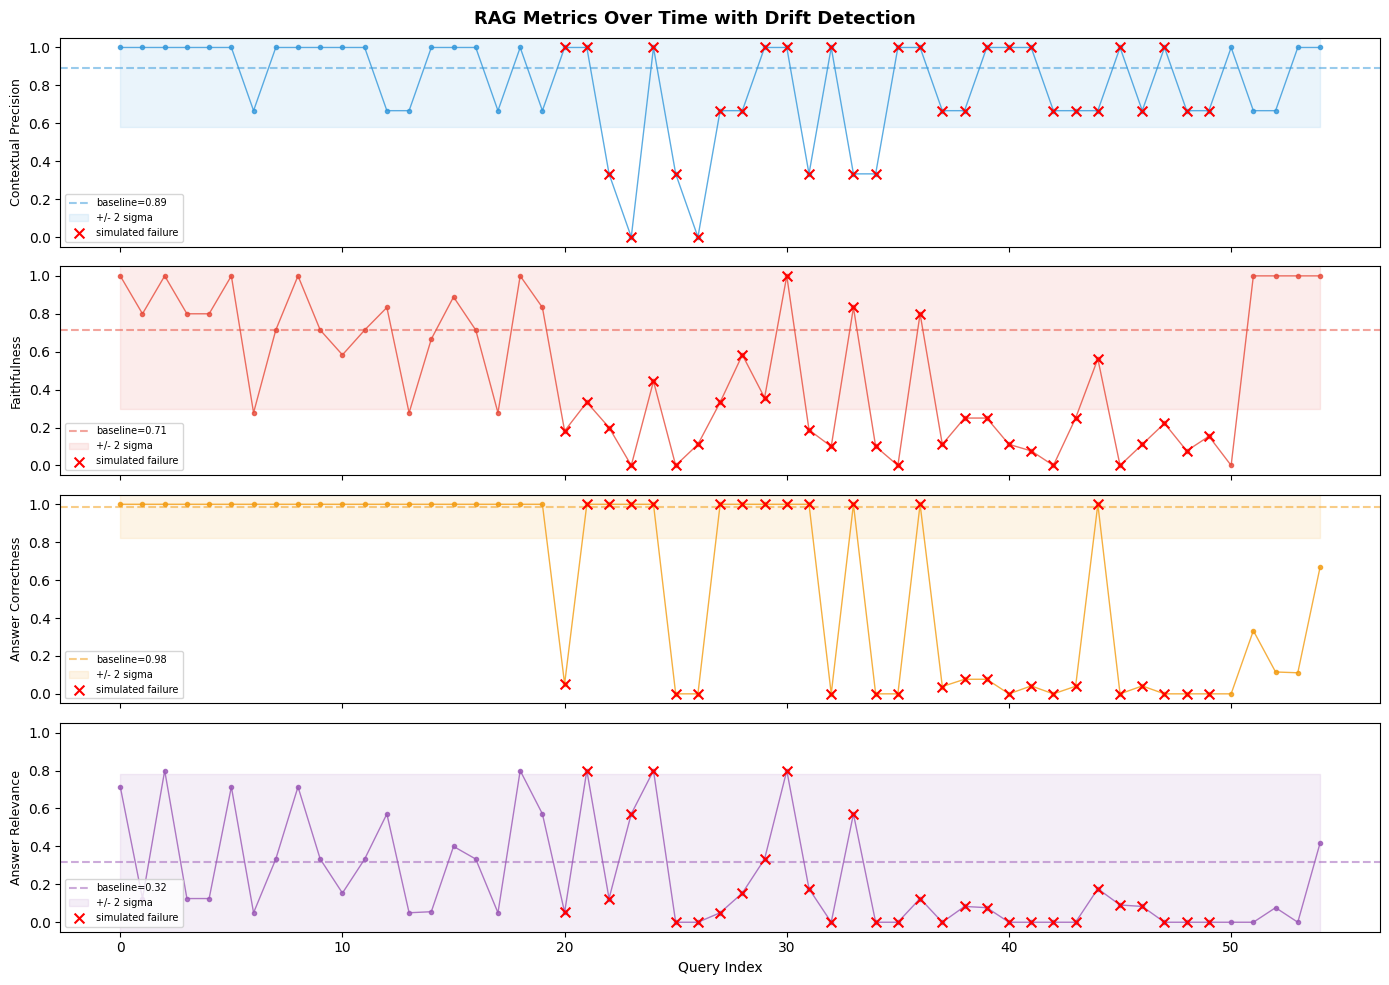

Saved: rag_drift_detection.png


In [9]:
# Plot all metrics over time
fig = system.plot_metrics(
    metrics=["contextual_precision", "faithfulness", "answer_correctness", "answer_relevance"],
    figsize=(14, 10)
)
if fig:
    plt.savefig("rag_drift_detection.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: rag_drift_detection.png")

In [10]:
# Detailed history as DataFrame
df = system.get_history_df()

# Show per-phase averages
print("Per-phase metric averages:")
print("=" * 80)

# Normal (first 20 after baseline)
normal = df[df["simulation_mode"].isna()].head(20)
noise = df[df["simulation_mode"] == "retrieval_noise"]
degrade = df[df["simulation_mode"] == "model_degradation"]

metrics = ["contextual_precision", "contextual_recall", "faithfulness", 
           "answer_relevance", "answer_correctness"]

comparison = pd.DataFrame({
    "Metric": metrics,
    "Normal": [normal[m].mean() for m in metrics],
    "Retrieval Noise": [noise[m].mean() for m in metrics] if len(noise) else [0]*5,
    "Model Degradation": [degrade[m].mean() for m in metrics] if len(degrade) else [0]*5,
})

# Add delta columns
comparison["Delta (Noise)"] = comparison["Retrieval Noise"] - comparison["Normal"]
comparison["Delta (Degradation)"] = comparison["Model Degradation"] - comparison["Normal"]

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print(comparison.to_string(index=False))

print("\nKey insight: Different failure modes affect different metrics.")
print("Retrieval noise drops PRECISION. Model degradation drops FAITHFULNESS.")
print("If you only monitored one metric, you'd miss half the failures.")

Per-phase metric averages:
              Metric  Normal  Retrieval Noise  Model Degradation  Delta (Noise)  Delta (Degradation)
contextual_precision   0.917            0.600              0.822         -0.317               -0.094
   contextual_recall   0.745            0.376              0.685         -0.369               -0.059
        faithfulness   0.745            0.318              0.198         -0.427               -0.546
    answer_relevance   0.368            0.296              0.042         -0.072               -0.325
  answer_correctness   1.000            0.670              0.154         -0.330               -0.846

Key insight: Different failure modes affect different metrics.
Retrieval noise drops PRECISION. Model degradation drops FAITHFULNESS.
If you only monitored one metric, you'd miss half the failures.


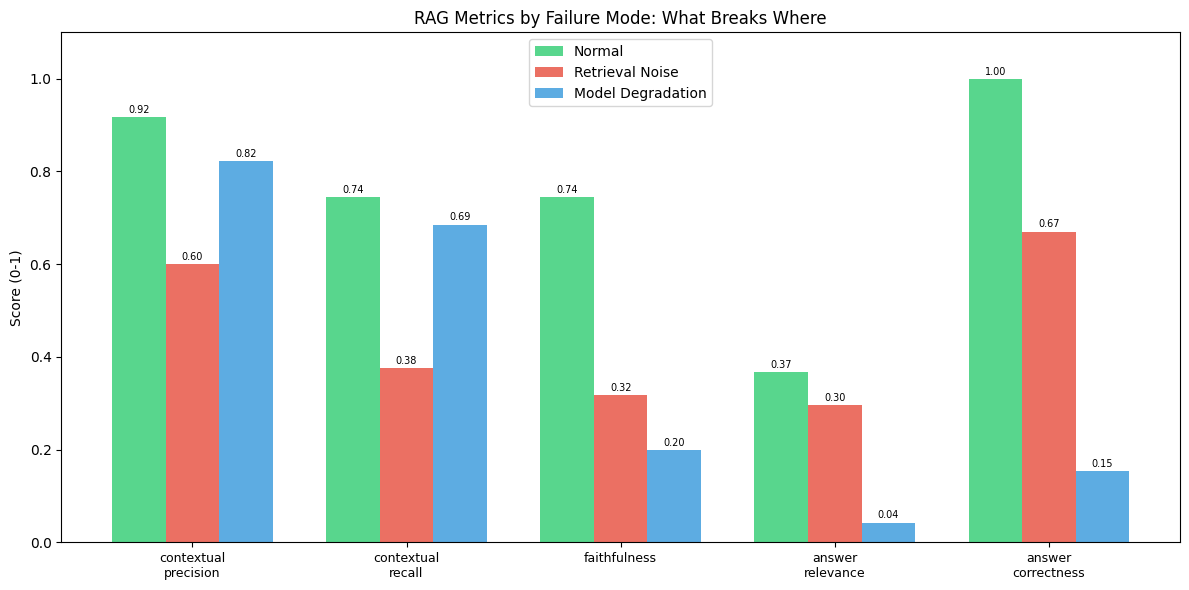

Saved: rag_failure_comparison.png


In [11]:
# Visual comparison of phases
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, comparison["Normal"], width, label="Normal", color="#2ecc71", alpha=0.8)
bars2 = ax.bar(x, comparison["Retrieval Noise"], width, label="Retrieval Noise", color="#e74c3c", alpha=0.8)
bars3 = ax.bar(x + width, comparison["Model Degradation"], width, label="Model Degradation", color="#3498db", alpha=0.8)

ax.set_ylabel("Score (0-1)")
ax.set_title("RAG Metrics by Failure Mode: What Breaks Where")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metrics], fontsize=9)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("rag_failure_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: rag_failure_comparison.png")

---
## What to Look For: Reading the Signs

### When Things Are Working
- All metrics stay within the baseline band (shaded area)
- No alerts fire
- Latency is stable
- Faithfulness > 0.6 (answer grounded in context)

### Retrieval Problems (vector DB, embeddings, indexing)
| Signal | What It Means |
|--------|--------------|
| Precision drops | Irrelevant chunks in top-K results |
| Recall drops | Relevant chunks not being found |
| Relevance drops | Retrieved content doesn't match query intent |
| Precision + Recall both drop | Embedding model or index is broken |

### Generation Problems (LLM, prompt, context handling)
| Signal | What It Means |
|--------|--------------|
| Faithfulness drops | LLM hallucinating beyond context |
| Correctness drops but faithfulness OK | Context is wrong, LLM is faithful to wrong info |
| Relevance drops | LLM going off-topic |
| All generation metrics drop | Model update broke instruction-following |

### System Problems
| Signal | What It Means |
|--------|--------------|
| Latency spikes | Infrastructure issue, model overloaded |
| Everything drops at once | Pipeline broken, not partial degradation |
| Intermittent drops | Rate limiting, timeout, connection issues |

---
## Production Integration Pattern

Here's how to integrate this into your actual RAG API:

In [12]:
# Production integration example
# This shows how you'd use the system in a real FastAPI RAG endpoint

INTEGRATION_CODE = '''
from rag_testing_system import RAGTestingSystem, RetrievedChunk, SyntheticRAGData

# Initialize once at startup
system = RAGTestingSystem(window_size=100)

# Run your test suite and establish baseline
test_results = run_your_test_suite()  # returns list[RAGResult]
system.establish_baseline(test_results)

# In your RAG endpoint:
@app.post("/query")
async def rag_query(request: QueryRequest):
    # 1. Your normal RAG pipeline
    chunks = retriever.search(request.query, top_k=5)
    answer = llm.generate(request.query, chunks)
    
    # 2. Wrap chunks for the testing system
    testing_chunks = [
        RetrievedChunk(text=c.text, score=c.score, source=c.source)
        for c in chunks
    ]
    
    # 3. Test and check for drift
    result, alerts = system.test_query(
        query=request.query,
        retrieved_chunks=testing_chunks,
        generated_answer=answer,
        latency_ms=response_time,
    )
    
    # 4. React to alerts
    for alert in alerts:
        if alert.severity == "critical":
            logger.critical(f"RAG drift: {alert.details}")
            send_pagerduty_alert(alert)
        elif alert.severity == "warning":
            logger.warning(f"RAG drift: {alert.details}")
    
    # 5. Log to Phoenix/observability
    # (automatic if OpenAI instrumentor is enabled)
    
    return {"answer": answer, "quality": result.faithfulness}
'''

print("Production integration pattern:")
print(INTEGRATION_CODE)

Production integration pattern:

from rag_testing_system import RAGTestingSystem, RetrievedChunk, SyntheticRAGData

# Initialize once at startup
system = RAGTestingSystem(window_size=100)

# Run your test suite and establish baseline
test_results = run_your_test_suite()  # returns list[RAGResult]
system.establish_baseline(test_results)

# In your RAG endpoint:
@app.post("/query")
async def rag_query(request: QueryRequest):
    # 1. Your normal RAG pipeline
    chunks = retriever.search(request.query, top_k=5)
    answer = llm.generate(request.query, chunks)

    # 2. Wrap chunks for the testing system
    testing_chunks = [
        RetrievedChunk(text=c.text, score=c.score, source=c.source)
        for c in chunks
    ]

    # 3. Test and check for drift
    result, alerts = system.test_query(
        query=request.query,
        retrieved_chunks=testing_chunks,
        generated_answer=answer,
        latency_ms=response_time,
    )

    # 4. React to alerts
    for alert in alerts:
 

---
## Appendix: All 7 Failure Modes

Run any of these to test your drift detection:

In [13]:
# Quick demo of all 7 failure modes
from rag_testing_system import FailureSimulator

sim = FailureSimulator()
print("Available failure modes:\n")
for mode in sim.MODES:
    print(f"  system.enable_simulation('{mode}', intensity=0.7)")

print("\nExample: testing all modes at intensity 0.5")
print("=" * 60)

calc = MetricsCalculator()
for mode in sim.MODES:
    sim.enable(mode, 0.7)
    tq = SyntheticRAGData.get_test_query()
    chunks, answer, latency = sim.apply(tq["chunks"], tq["answer"], 100.0)
    
    r = RAGResult(query=tq["query"], retrieved_chunks=chunks,
                  generated_answer=answer, ground_truth=tq["ground_truth"])
    calc.calculate_all(r)
    
    print(f"  {mode:25s}  prec={r.contextual_precision:.2f}  faith={r.faithfulness:.2f}  "
          f"correct={r.answer_correctness:.2f}  latency={latency:.0f}ms")
    sim.disable()

Available failure modes:

  system.enable_simulation('embedding_drift', intensity=0.7)
  system.enable_simulation('retrieval_noise', intensity=0.7)
  system.enable_simulation('context_truncation', intensity=0.7)
  system.enable_simulation('model_degradation', intensity=0.7)
  system.enable_simulation('latency_spike', intensity=0.7)
  system.enable_simulation('staleness', intensity=0.7)
  system.enable_simulation('index_corruption', intensity=0.7)

Example: testing all modes at intensity 0.5
  embedding_drift            prec=0.67  faith=0.28  correct=1.00  latency=100ms
  retrieval_noise            prec=0.33  faith=0.18  correct=0.00  latency=100ms
  context_truncation         prec=1.00  faith=0.50  correct=1.00  latency=100ms
  model_degradation          prec=1.00  faith=0.58  correct=1.00  latency=100ms
  latency_spike              prec=0.67  faith=0.28  correct=1.00  latency=695ms
  staleness                  prec=0.67  faith=0.89  correct=1.00  latency=100ms
  index_corruption      

---
## Summary

This system gives you three capabilities:

1. **Measure** — 5 metrics on every RAG query (precision, recall, faithfulness, relevance, correctness)
2. **Detect** — Statistical drift detection (t-test + Cohen's d) with configurable alert thresholds
3. **Simulate** — 7 failure modes to validate your monitoring before production breaks

**The key insight:** Different failures break different metrics. If you only monitor one number, you're blind to half the problems. Monitor all five, and you'll catch retrieval issues, generation issues, and system issues independently.

Traces are available in Phoenix at http://localhost:6006 (project: rag-testing).